<a href="https://colab.research.google.com/github/Dhanushyapalaparvi/smart-energy-consumption-forecasting-using-anfis/blob/main/SoftComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ysrisaidhanush
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set


100%|██████████| 19.4M/19.4M [00:02<00:00, 7.23MB/s]


In [3]:
import pandas as pd
path = './electric-power-consumption-data-set/household_power_consumption.txt'


In [4]:
df = pd.read_csv(path,sep = ';',
                 parse_dates = {'dt': ['Date','Time']},
                 infer_datetime_format=True,
                 low_memory=False,
                 na_values = ['?'],
                 index_col ='dt'
                 )

/tmp/ipykernel_24631/3122458557.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(path,sep = ';',
/tmp/ipykernel_24631/3122458557.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(path,sep = ';',
/tmp/ipykernel_24631/3122458557.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(path,sep = ';',


In [5]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
# filling missing values using interpolation
df = df.astype('float32')
df.interpolate(method = 'linear')

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.839996,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.630005,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.289993,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.740005,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.679993,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.429993,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.000000,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.820007,3.8,0.0,0.0,0.0


In [7]:
# the current power consumption is minute we'll convert it into hourly
df_hourly = df.resample('h').mean()
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643875,18.099998,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580154,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232498,14.503333,0.0,1.433333,16.683332
2006-12-16 20:00:00,3.268567,0.075100,234.071503,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158661,13.046666,0.0,0.416667,17.216667


In [8]:
from sklearn.preprocessing import MinMaxScaler
# feature extraction
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].apply(lambda x: 1 if x>=5 else 0)

In [9]:
scaler = MinMaxScaler(feature_range = (0,1))
df_hourly['scaled_power'] = scaler.fit_transform(df_hourly[['Global_active_power']])

Data prepation for training

In [10]:
import numpy as np

In [11]:
def create_anfis_dataset(df,n_lags=3):
  X,y = [],[]
  for i in range(len(df)-n_lags):
    lags = df['scaled_power'].iloc[i:i+n_lags].values
    hour_norm = df['hour'].iloc[i+n_lags]/23.0
    weekend = df['is_weekend'].iloc[i+n_lags]
    combined_input = np.append(lags,[hour_norm,weekend])
    X.append(combined_input)
    y.append(df['scaled_power'].iloc[i+n_lags])
  return np.array(X),np.array(y)
X,y = create_anfis_dataset(df_hourly)

splitting data as train and test data

In [12]:
split_idx = int(len(X)*0.8)
X_train,X_test = X[:split_idx],X[split_idx:]
y_train,y_test= y[:split_idx],y[split_idx:]
print(f"total samples: {len(X)}")
print(f"training shape: {X_train.shape}")
print(f"testing shape: {X_test.shape}")

total samples: 34586
training shape: (27668, 5)
testing shape: (6918, 5)


In [13]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

visualizing daily energy profile

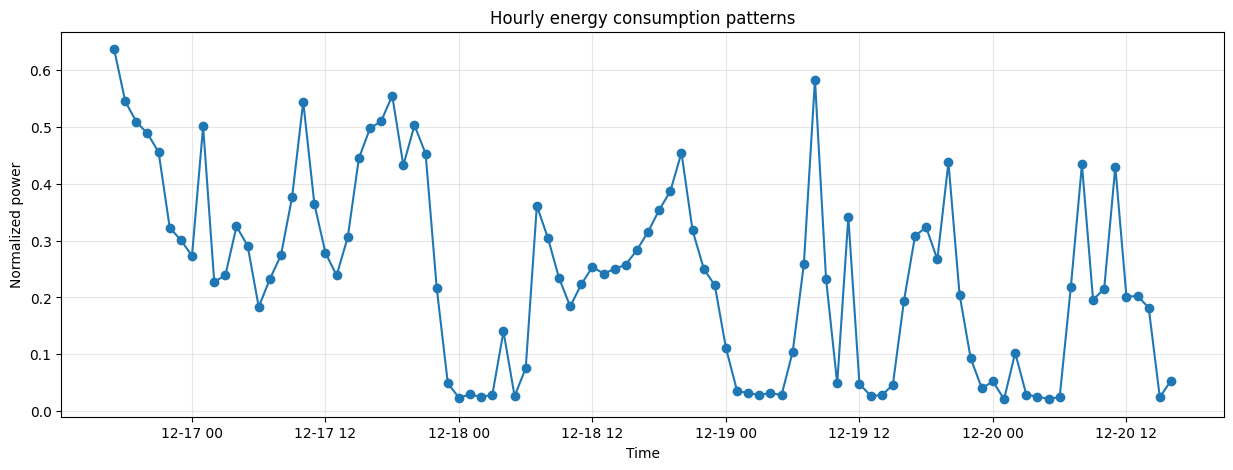

In [14]:
plt.figure(figsize=(15,5))
plt.plot(df_hourly['scaled_power'][:96],marker = 'o',linestyle = '-',color = 'tab:blue')
plt.title("Hourly energy consumption patterns")
plt.xlabel('Time')
plt.ylabel('Normalized power')
plt.grid(True,alpha = 0.3)
plt.show()

Checking and visualizing autocorrelation

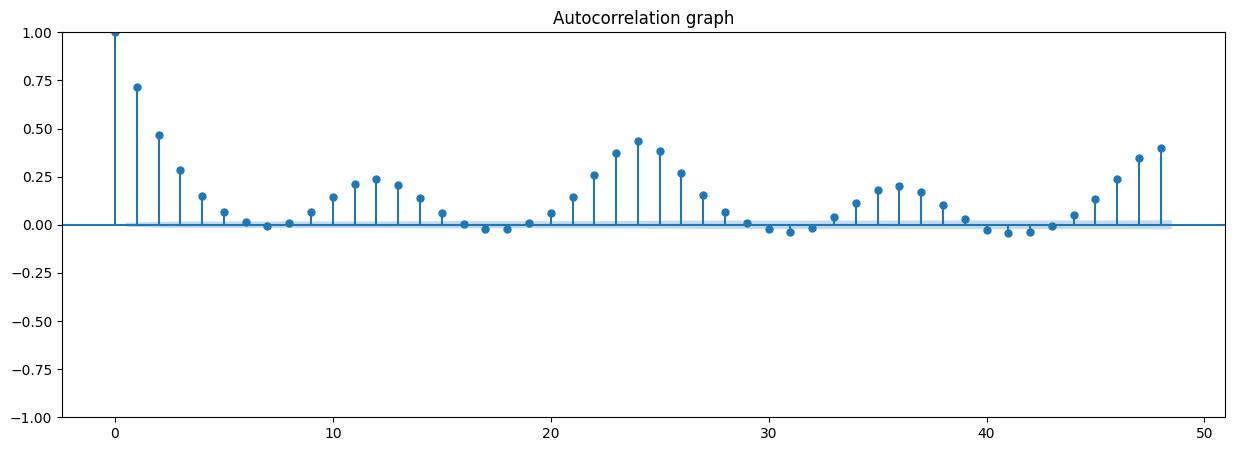

In [18]:
power_values = df_hourly['Global_active_power'].dropna().values
plt.figure(figsize=(15,5))
plot_acf(power_values,lags = 48,ax = plt.gca())
plt.title("Autocorrelation graph")
plt.show()

In [19]:
import torch
import torch.nn as nn
class ANFIS_Layer1(nn.Module):
  def __init__(self,n_inputs,n_rules):
    super(ANFIS_Layer1,self).__init__()
    self.c = nn.Parameter(torch.randn(n_inputs,n_rules))
    self.sigma = nn.Parameter(torch.ones(n_inputs,n_rules))
  def forward(self,x):
    x = x.unsqueeze(2)
    mu = torch.exp(-0.5*torch.pow((x-self.c)/self.sigma,2))
    return mu

In [20]:
class SmartEnergyANFIS(nn.Module):
  def __init__(self,n_inputs,n_rules):
    super(SmartEnergyANFIS,self).__init__()
    self.n_inputs = n_inputs
    self.n_rules = n_rules
    self.layer1 = ANFIS_Layer1(n_inputs,n_rules)
    self.consequent_params = nn.Parameter(torch.randn(n_rules,n_inputs+1))
  def forward(self,x):
    batch_size = x.shape[0]
    mu = self.layer1(x)
    w = torch.prod(mu,dim=1)
    w_sum = torch.sum(w,dim=1,keepdim = True)+ 1e-8
    w_norm = w/w_sum
    x_with_bias = torch.cat([x,torch.ones(batch_size,1)],dim=1)
    f = torch.matmul(x_with_bias,self.consequent_params.T)
    output = torch.sum(w_norm*f,dim=1)
    return output

In [21]:
X_train_t = torch.tensor(X_train,dtype = torch.float32)
y_train_t = torch.tensor(y_train,dtype = torch.float32)
model = SmartEnergyANFIS(n_inputs=5,n_rules =3)
optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)
loss = nn.MSELoss()